In [1]:
"""Complete pipeline for wav2sleep training on CFS sleep staging task.

This example demonstrates the full training pipeline for the wav2sleep model
on the Cleveland Family Study (CFS) dataset following PyHealth implementation
requirements:

1. **Data Loading**: Load CFS dataset with automatic sleep staging task
2. **Dataset Configuration**: Multi-modal setup with EEG, EOG, EMG, ECG signals
3. **Model Initialization**: Wav2Sleep with configurable architecture for CFS modalities
4. **Training Loop**: Using the wav2sleep-specific trainer with:
   - AdamW optimizer
   - Linear warmup to max learning rate
   - Exponential decay schedule
   - Early stopping when validation loss plateaus (5 epochs patience)
5. **Evaluation**: Cross-modal evaluation showing model robustness
6. **Reproducibility**: Seed control, configurable subset sizes

Wav2Sleep paper link:
    https://doi.org/10.48550/arXiv.2411.04644

Wav2Sleep paper citation:
    Carter, J. F.; and Tarassenko, L. 2024. wav2sleep: A unified multi-modal approach
    to sleep stage classification from physiological signals. arXiv preprint arXiv:2411.04644.

Authors:
    Austin Jarrett (ajj7@illinois.edu)
    Justin Cheok (jcheok2@illinois.edu)
    Jimmy Scray (escray2@illinois.edu)

CFS Dataset:
    The Cleveland Family Study (CFS) is a longitudinal cohort study with
    polysomnography recordings. Each recording contains multiple physiological
    signals: EEG, left/right EOG, chin EMG, ECG, and optionally PPG.
    Note: PPG (plethysmograph) is available in ~43% of CFS files.

Requirements:
    - CFS data: Set CFS_ROOT to use real data (must be requested from NSRR)
    - Or: Notebook will use fully synthetic data for demonstration

Usage Examples:
    # Quick test with synthetic data (2 min)
    Set EPOCHS = 1 and run all cells

    # Full training with 2% of CFS data (~37 patients, ~20 min on CPU)
    Set CFS_ROOT, SUBSET_FRACTION = 0.02, EPOCHS = 50, BATCH_SIZE = 8

    # Training with PPG as additional modality (missing PPG zero-padded)
    Set INCLUDE_PPG = True, PPG_SAMPLES = 256

    # Production training with full dataset
    Set CFS_ROOT, EPOCHS = 80, BATCH_SIZE = 32, DEVICE = "cuda"
"""

'Complete pipeline for wav2sleep training on CFS sleep staging task.\n\nThis example demonstrates the full training pipeline for the wav2sleep model\non the Cleveland Family Study (CFS) dataset following PyHealth implementation\nrequirements:\n\n1. **Data Loading**: Load CFS dataset with automatic sleep staging task\n2. **Dataset Configuration**: Multi-modal setup with EEG, EOG, EMG, ECG signals\n3. **Model Initialization**: Wav2Sleep with configurable architecture for CFS modalities\n4. **Training Loop**: Using the wav2sleep-specific trainer with:\n   - AdamW optimizer\n   - Linear warmup to max learning rate\n   - Exponential decay schedule\n   - Early stopping when validation loss plateaus (5 epochs patience)\n5. **Evaluation**: Cross-modal evaluation showing model robustness\n6. **Reproducibility**: Seed control, configurable subset sizes\n\nWav2Sleep paper link:\n    https://doi.org/10.48550/arXiv.2411.04644\n\nWav2Sleep paper citation:\n    Carter, J. F.; and Tarassenko, L. 2024.

In [2]:
import logging
import os
from datetime import datetime
from pathlib import Path
from typing import Optional

import numpy as np
import torch

from pyhealth.datasets import create_sample_dataset, get_dataloader
from pyhealth.models import Wav2Sleep
from pyhealth.training.wav2sleep_trainer import Wav2SleepTrainer, create_subset_loaders
from pyhealth.metrics.wav2sleep import compute_confusion_matrix, cohens_kappa

In [3]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
)
logger = logging.getLogger(__name__)

# Suppress verbose warnings from CFS dataset loader
logging.getLogger("pyhealth.datasets.cfs").setLevel(logging.ERROR)
logging.getLogger("pyhealth.datasets").setLevel(logging.ERROR)

In [4]:
# =============================================================================
# Configuration
# =============================================================================

# Sleep stage label definitions (AASM 5-class)
SLEEP_STAGES = {0: "Wake", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
NUM_CLASSES = len(SLEEP_STAGES)

# Signal sampling parameters handled by SleepStagingCFS task:
# - EEG: 256 samples (~8 Hz × 30 s, downsampled from 200 Hz)
# - EOG-L/R: 256 samples (~8 Hz × 30 s)
# - EMG: 128 samples (~4 Hz × 30 s)
# - ECG: 256 samples (~8 Hz × 30 s)
# These values should match the task constructor if customized.
EEG_SAMPLES_PER_EPOCH = 256    # For reference, matches task default
EOG_SAMPLES_PER_EPOCH = 256    # For reference, matches task default
EMG_SAMPLES_PER_EPOCH = 128    # For reference, matches task default
ECG_SAMPLES_PER_EPOCH = 256    # For reference, matches task default
PPG_SAMPLES_PER_EPOCH = 256    # For reference, PPG sample count (optional)

In [ ]:
# =============================================================================
# Hyperparameters Configuration
# =============================================================================

# Set random seeds for reproducibility
# np.random.seed(42)
# torch.manual_seed(42)

# ===== Dataset Configuration =====
CFS_ROOT = "/path/to/cfs"             # Path to CFS dataset root directory. If None, synthetic data is used
MAX_RECORDINGS = None       # Maximum number of CFS recordings to load (None = load all)
SUBSET_FRACTION = 0.05      # Fraction of CFS dataset to load (0.0 to 1.0). Load 2% of patients (~37 patients)

# ===== PPG Options (optional modality) =====
INCLUDE_PPG = True         # Include PPG (plethysmograph) as additional modality (~43% of CFS files have it; missing values are zero-padded)
PPG_SAMPLES = 256           # Target sample count for PPG after resampling

# ===== Training Data Configuration =====
TRAIN_FRACTION = 0.8        # Fraction of loaded data to use for training (0.0 to 1.0)
VAL_FRACTION = 0.2          # Fraction of remaining data to use for validation (0.0 to 1.0)

# ===== Training Hyperparameters (from wav2sleep paper) =====
EPOCHS = 30                 # Number of training epochs
BATCH_SIZE = 16             # Batch size for training
WARMUP_FRACTION = 0.1       # Fraction of training steps used for linear warmup
MAX_LR = 1e-3               # Maximum learning rate (at end of warmup phase)
DECAY_RATE = 0.9999         # Exponential decay rate per step (lambda^step). Higher = slower decay
WEIGHT_DECAY = 1e-2         # L2 regularization coefficient (AdamW weight decay)
PATIENCE = 30               # Early stopping patience (epochs with no improvement, from paper)

# ===== System Configuration =====
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Device for training
OUTPUT_DIR = "output"       # Directory for saving checkpoints and logs

logger.info(f"Configuration: INCLUDE_PPG={INCLUDE_PPG}, PPG_SAMPLES={PPG_SAMPLES}")

2026-04-21 17:42:15,386 - __main__ - INFO - Configuration: INCLUDE_PPG=True, PPG_SAMPLES=256


In [6]:
# =============================================================================
# Dataset Construction
# =============================================================================

def build_synthetic_cfs_dataset(n_samples: int = 100, include_ppg: bool = False) -> object:
    """Create a synthetic CFS dataset for testing/demonstration.
    
    Generates random multi-modal polysomnography signals (EEG, EOG, EMG, ECG, optionally PPG)
    with random sleep stage labels. Useful for testing the training pipeline
    when real CFS data is unavailable.
    
    Args:
        n_samples: Number of synthetic samples to generate. Default: 100.
        include_ppg: Whether to include PPG modality. Default: False.
        
    Returns:
        PyHealth SampleDataset with synthetic CFS data in wav2sleep format.
    """
    logger.info(f"Generating {n_samples} synthetic samples (include_ppg={include_ppg})...")
    
    synthetic_samples = []
    for i in range(n_samples):
        sample = {
            "patient_id": f"synthetic_{i // 10}",  # 10 samples per synthetic patient
            "study_id": f"synthetic_{i // 10}_study",
            "patient_age": np.random.randint(30, 80),
            "patient_sex": np.random.randint(0, 2),
            "eeg": np.random.randn(EEG_SAMPLES_PER_EPOCH).astype(np.float32),
            "eog_left": np.random.randn(EOG_SAMPLES_PER_EPOCH).astype(np.float32),
            "eog_right": np.random.randn(EOG_SAMPLES_PER_EPOCH).astype(np.float32),
            "emg": np.random.randn(EMG_SAMPLES_PER_EPOCH).astype(np.float32),
            "ecg": np.random.randn(ECG_SAMPLES_PER_EPOCH).astype(np.float32),
            "label": np.random.randint(0, 5),  # 5 sleep stages: 0-4
        }
        if include_ppg:
            sample["ppg"] = np.random.randn(PPG_SAMPLES_PER_EPOCH).astype(np.float32)
        synthetic_samples.append(sample)
    
    input_schema = {
        "eeg": "tensor",
        "eog_left": "tensor",
        "eog_right": "tensor",
        "emg": "tensor",
        "ecg": "tensor",
    }
    if include_ppg:
        input_schema["ppg"] = "tensor"
    
    dataset = create_sample_dataset(
        samples=synthetic_samples,
        input_schema=input_schema,
        output_schema={"label": "multiclass"},
        dataset_name="synthetic_cfs_wav2sleep",
    )
    
    logger.info(f"✓ Generated {len(synthetic_samples)} synthetic samples")
    return dataset

In [7]:
def load_cfs_or_synthetic(
    cfs_root: Optional[str] = None,
    max_recordings: Optional[int] = None,
    subset_fraction: Optional[float] = None,
    include_ppg: bool = False,
    ppg_samples: int = 256,
) -> object:
    """Load CFS dataset if available, otherwise create synthetic fallback.
    
    The NSRR CFS dataset must have:
    - polysomnography/edfs/*.edf (signal files)
    - polysomnography/annotations-events-nsrr/*.xml (sleep stage annotations)
    - polysomnography/annotations-events-profusion/*.xml (alternative annotations)
    
    This function generates polysomnography-metadata-pyhealth.csv from the NSRR
    dataset structure and passes it to PyHealth's CFSDataset.
    
    Args:
        cfs_root: Path to CFS dataset root directory.
            If None or invalid, synthetic data is used.
        max_recordings: Maximum number of recordings to load from CFS.
            If None, all available recordings are loaded.
        subset_fraction: Fraction of dataset to load (0.0 to 1.0).
            If specified, limits the dataset size to this fraction.
            Applied at the dataset level before loading, more efficient than 
            post-hoc subsampling.
        include_ppg: Whether to include PPG modality (only in ~43% of CFS files,
            missing values are zero-padded). Default: False.
        ppg_samples: Target sample count for PPG after resampling. Default: 256.
    Returns:
        PyHealth SampleDataset in wav2sleep format.
    """
    if cfs_root and os.path.isdir(cfs_root):
        try:
            from pyhealth.datasets import CFSDataset
            from pyhealth.tasks import SleepStagingCFS
            
            logger.info(f"Attempting to load CFS dataset from: {cfs_root}")
            
            # Load CFS dataset with optional subset
            cfs_dataset = CFSDataset(root=cfs_root, dev=False)
            
            # Apply subset if requested (limits patient count efficiently)
            if subset_fraction is not None and subset_fraction < 1.0:
                patients_to_load = cfs_dataset.unique_patient_ids
                n_patients = max(1, int(len(patients_to_load) * subset_fraction))
                sampled_patients = np.random.choice(
                    patients_to_load, size=n_patients, replace=False
                )
                logger.info(f"Loading {n_patients} / {len(patients_to_load)} patients ({subset_fraction*100:.1f}%)")
                
                # Process only sampled patients
                samples = []
                task = SleepStagingCFS(preload=False, include_ppg=include_ppg, ppg_samples=ppg_samples)
                for pid in sampled_patients:
                    patient = cfs_dataset.get_patient(pid)
                    samples.extend(task(patient))
            else:
                # Load all records (via task)
                logger.info(f"Loading all available records")
                task = SleepStagingCFS(preload=False, include_ppg=include_ppg, ppg_samples=ppg_samples)
                samples = []
                for pid in cfs_dataset.unique_patient_ids:
                    patient = cfs_dataset.get_patient(pid)
                    samples.extend(task(patient))
                    if max_recordings and len(samples) >= max_recordings:
                        samples = samples[:max_recordings]
                        break
            
            if not samples:
                logger.warning(f"CFS loader returned 0 samples. Falling back to synthetic data.")
                return build_synthetic_cfs_dataset()
            
            logger.info(f"✓ Loaded {len(samples)} CFS samples in wav2sleep format")
            
            # Task already outputs wav2sleep format
            # Build input schema based on whether PPG is included
            input_schema = {
                "eeg": "tensor",
                "eog_left": "tensor",
                "eog_right": "tensor",
                "emg": "tensor",
                "ecg": "tensor",
            }
            if include_ppg:
                input_schema["ppg"] = "tensor"
                logger.info(f"  (PPG included in {sum(1 for s in samples if 'ppg' in s)}/{len(samples)} samples)")
            
            dataset = create_sample_dataset(
                samples=samples,
                input_schema=input_schema,
                output_schema={"label": "multiclass"},
                dataset_name="cfs_wav2sleep",
            )
            return dataset
        except Exception as e:
            logger.error(f"Error loading CFS dataset: {type(e).__name__}: {e}", exc_info=True)
            logger.info("Falling back to synthetic data.")
            return build_synthetic_cfs_dataset()
    else:
        if cfs_root:
            logger.warning(f"CFS_ROOT directory not found: {cfs_root}")
        logger.info("Using synthetic data for training.")
        return build_synthetic_cfs_dataset(include_ppg=include_ppg)

In [8]:
# =============================================================================
# Model Training
# =============================================================================

def train_wav2sleep_model(
    dataset,
    train_fraction: float = 0.8,
    val_fraction: float = 0.2,
    batch_size: int = 32,
    epochs: int = 80,
    warmup_fraction: float = 0.1,
    max_lr: float = 1e-3,
    decay_rate: float = 0.9999,
    weight_decay: float = 1e-2,
    patience: int = 5,
    device: Optional[str] = None,
    output_dir: str = "output",
) -> tuple:
    """Train wav2sleep model on CFS dataset with specified hyperparameters.
    This function implements the complete training pipeline described in the
    wav2sleep paper with:
    - AdamW optimizer (no weight decay on bias/norm parameters)
    - Linear warmup phase: 0 → max_lr over warmup_fraction of training
    - Exponential decay phase: max_lr → ~0 with decay_rate^step
    - Early stopping: patience=5 (as per paper) means training stops if
      validation loss doesn't improve for 5 consecutive epochs
    - Optional subset training for memory-constrained environments
    Args:
        dataset: PyHealth SampleDataset with CFS data.
        train_fraction: Fraction of training set to use (0.0 to 1.0).
            Default: 0.8 (use 80% for training).
        val_fraction: Fraction of validation set to use (0.0 to 1.0).
            Default: 0.2 (use 20% for validation).
        batch_size: Batch size for training. Default: 32.
        epochs: Maximum number of epochs. Default: 80.
        warmup_fraction: Fraction of training steps for linear warmup.
            Default: 0.1 (10% of training are warmup).
        max_lr: Maximum learning rate (reached at end of warmup).
            Default: 1e-3.
        decay_rate: Exponential decay factor per step.
            Default: 0.9999 (smooth decay).
            Higher values → slower decay, lower values → faster decay.
        weight_decay: L2 regularization coefficient. Default: 1e-2.
        patience: Early stopping patience. Default: 5 (as per wav2sleep paper).
        device: Device for training ('cuda' or 'cpu'). Auto-detect if None.
        output_dir: Directory for saving checkpoints and logs. Default: 'output'.
    Returns:
        Tuple of (history dict, trainer, model):
        - history: Training history with 'train_loss', 'val_loss', 'val_accuracy'
        - trainer: Wav2SleepTrainer instance
        - model: Trained Wav2Sleep model
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    # Create data loaders
    train_loader, val_loader = create_subset_loaders(
        dataset=dataset,
        train_fraction=train_fraction,
        val_fraction=val_fraction,
        batch_size=batch_size,
        seed=42,
    )
    # Create model
    model = Wav2Sleep(
        dataset=dataset,
        feature_dim=128,
        n_transformer_layers=2,
        n_attention_heads=8,
        transformer_ff_dim=512,
        dropout=0.1,
    )
    # Create trainer
    trainer = Wav2SleepTrainer(
        model=model,
        device=device,
        enable_logging=True,
        output_path=output_dir,
        exp_name="wav2sleep_cfs_training",
    )
    logger.info(f"Training: {sum(p.numel() for p in model.parameters()):,} parameters, {epochs} epochs, device={device}")
    # Train
    history = trainer.train_with_schedule(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=epochs,
        warmup_fraction=warmup_fraction,
        max_lr=max_lr,
        decay_rate=decay_rate,
        weight_decay=weight_decay,
        max_grad_norm=1.0,
        patience=patience,
    )
    return history, trainer, model

In [9]:
# =============================================================================
# Evaluation & Analysis
# =============================================================================

def evaluate_modality_subset(
    model,
    val_loader,
    subset_keys: list,
    device: str = "cuda",
) -> tuple:
    """Evaluate model on subset of modalities (cross-modal generalization).
    This demonstrates the key feature of wav2sleep: the same trained model
    can work with any subset of input modalities without retraining.
    Args:
        model: Trained Wav2Sleep model.
        val_loader: Validation data loader.
        subset_keys: List of modality names to keep (e.g., ['eeg']).
        device: Device for evaluation.
    Returns:
        Tuple of (mean_loss, accuracy).
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for batch in val_loader:
            # Keep only requested modalities
            filtered_batch = {
                k: v for k, v in batch.items()
                if k in subset_keys or k == "label"
            }
            output = model(**filtered_batch)
            loss = output["loss"].item() * len(output["y_true"])
            total_loss += loss
            preds = output["y_prob"].argmax(dim=-1)
            total_correct += (preds == output["y_true"]).sum().item()
            total_samples += len(output["y_true"])
    mean_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return mean_loss, accuracy

In [10]:
def print_results_summary(history, model, val_loader, device="cpu"):
    """Print concise training results summary."""
    logger.info("\nTraining Results:")
    if history.get('train_loss'):
        logger.info(f"  Initial loss: {history['train_loss'][0]:.6f}, Final loss: {history['train_loss'][-1]:.6f}")
    if history.get('val_loss'):
        logger.info(f"  Best val loss: {min(history['val_loss']):.6f}")
    if history.get('val_accuracy'):
        logger.info(f"  Best val accuracy: {max(history['val_accuracy']):.4f}")
    
    # Compute Cohen's Kappa on validation set
    if val_loader:
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for batch in val_loader:
                output = model(**batch)
                preds = output["y_prob"].argmax(dim=-1)
                labels = output["y_true"]
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        # Compute confusion matrix and Cohen's Kappa
        cmat = compute_confusion_matrix(all_preds, all_labels, num_classes=NUM_CLASSES)
        kappa = cohens_kappa(cmat)
        
        logger.info(f"  Cohen's Kappa: {kappa:.4f}")

In [11]:
# =============================================================================
# Pipeline Step 1/4: Load Dataset for Run 1
# =============================================================================
logger.info("=" * 70)
logger.info("WAV2SLEEP: Sleep Stage Classification Pipeline")
logger.info("=" * 70)
logger.info("")
logger.info("Paper: Carter & Tarassenko, arXiv:2411.04644")
logger.info("Dataset: Cleveland Family Study (CFS)")
logger.info("Implementation: PyHealth")
logger.info("")
logger.info("[Step 1/4] Loading dataset...")

dataset = load_cfs_or_synthetic(
    cfs_root=CFS_ROOT,
    max_recordings=MAX_RECORDINGS,
    subset_fraction=SUBSET_FRACTION,
    include_ppg=INCLUDE_PPG,
    ppg_samples=PPG_SAMPLES,
)
logger.info(f"  ✓ Loaded {len(dataset)} samples")

2026-04-21 17:42:15,432 - __main__ - INFO - ======================================================================
2026-04-21 17:42:15,433 - __main__ - INFO - WAV2SLEEP: Sleep Stage Classification Pipeline
2026-04-21 17:42:15,433 - __main__ - INFO - ======================================================================
2026-04-21 17:42:15,433 - __main__ - INFO - 
2026-04-21 17:42:15,433 - __main__ - INFO - Paper: Carter & Tarassenko, arXiv:2411.04644
2026-04-21 17:42:15,434 - __main__ - INFO - Dataset: Cleveland Family Study (CFS)
2026-04-21 17:42:15,434 - __main__ - INFO - Implementation: PyHealth
2026-04-21 17:42:15,434 - __main__ - INFO - 
2026-04-21 17:42:15,434 - __main__ - INFO - [Step 1/4] Loading dataset...
2026-04-21 17:42:15,434 - __main__ - INFO - Attempting to load CFS dataset from: /Users/austinjarrett/Desktop/PyHealth-proj/cfs
2026-04-21 17:42:15,441 - __main__ - INFO - Loading 36 / 735 patients (5.0%)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

2026-04-21 17:43:44,583 - __main__ - INFO - ✓ Loaded 1080 CFS samples in wav2sleep format
2026-04-21 17:43:44,586 - __main__ - INFO -   (PPG included in 1080/1080 samples)


Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


2026-04-21 17:43:44,600 - pyhealth.processors.label_processor - INFO - Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
2026-04-21 17:43:44,644 - __main__ - INFO -   ✓ Loaded 1080 samples


In [12]:
# =============================================================================
# Pipeline Step 2/4: Train Model
# =============================================================================
logger.info("\n[Step 2/4] Training model with paper-specific schedule...")
history1, trainer1, model1 = train_wav2sleep_model(
    dataset=dataset,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    warmup_fraction=WARMUP_FRACTION,
    max_lr=MAX_LR,
    decay_rate=DECAY_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

2026-04-21 17:43:44,656 - __main__ - INFO - 
[Step 2/4] Training model with paper-specific schedule...
/Users/austinjarrett/Desktop/PyHealth-proj/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
2026-04-21 17:43:44,707 - __main__ - INFO - Training: 2,782,533 parameters, 30 epochs, device=cpu



Epoch | Train Loss | Val Loss | Val Accuracy


2026-04-21 17:43:44,709 - pyhealth.training.wav2sleep_trainer - INFO - 
Epoch | Train Loss | Val Loss | Val Accuracy


--------------------------------------------------


2026-04-21 17:43:44,709 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------


...

2026-04-21 17:49:49,079 - pyhealth.training.wav2sleep_trainer - INFO -    29 |   1.211168 | 1.568278 |       0.6977


   30 |   0.552505 | 5.855263 |       0.5349


2026-04-21 17:50:02,357 - pyhealth.training.wav2sleep_trainer - INFO -    30 |   0.552505 | 5.855263 |       0.5349


--------------------------------------------------



2026-04-21 17:50:02,568 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------



In [13]:
# =============================================================================
# Load Dataset for Run 2
# =============================================================================
logger.info("=" * 70)
logger.info("WAV2SLEEP: Sleep Stage Classification Pipeline")
logger.info("=" * 70)
logger.info("")
logger.info("Paper: Carter & Tarassenko, arXiv:2411.04644")
logger.info("Dataset: Cleveland Family Study (CFS)")
logger.info("Implementation: PyHealth")
logger.info("")
logger.info("[Step 1/4] Loading dataset...")

dataset = load_cfs_or_synthetic(
    cfs_root=CFS_ROOT,
    max_recordings=MAX_RECORDINGS,
    subset_fraction=SUBSET_FRACTION,
    include_ppg=INCLUDE_PPG,
    ppg_samples=PPG_SAMPLES,
)
logger.info(f"  ✓ Loaded {len(dataset)} samples")

2026-04-21 17:50:02,603 - __main__ - INFO - ======================================================================
2026-04-21 17:50:02,604 - __main__ - INFO - WAV2SLEEP: Sleep Stage Classification Pipeline
2026-04-21 17:50:02,604 - __main__ - INFO - ======================================================================
2026-04-21 17:50:02,604 - __main__ - INFO - 
2026-04-21 17:50:02,605 - __main__ - INFO - Paper: Carter & Tarassenko, arXiv:2411.04644
2026-04-21 17:50:02,605 - __main__ - INFO - Dataset: Cleveland Family Study (CFS)
2026-04-21 17:50:02,606 - __main__ - INFO - Implementation: PyHealth
2026-04-21 17:50:02,606 - __main__ - INFO - 
2026-04-21 17:50:02,607 - __main__ - INFO - [Step 1/4] Loading dataset...
2026-04-21 17:50:02,607 - __main__ - INFO - Attempting to load CFS dataset from: /Users/austinjarrett/Desktop/PyHealth-proj/cfs
2026-04-21 17:50:02,612 - __main__ - INFO - Loading 36 / 735 patients (5.0%)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

2026-04-21 17:51:30,956 - __main__ - INFO - ✓ Loaded 1036 CFS samples in wav2sleep format
2026-04-21 17:51:30,956 - __main__ - INFO -   (PPG included in 1036/1036 samples)


Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


2026-04-21 17:51:30,958 - pyhealth.processors.label_processor - INFO - Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
2026-04-21 17:51:30,991 - __main__ - INFO -   ✓ Loaded 1036 samples


In [14]:
# Pipeline Step 2/4: Train Model (Run 2)
logger.info("\n[Step 2/4] Training model with paper-specific schedule...")
history2, trainer2, model2 = train_wav2sleep_model(
    dataset=dataset,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    warmup_fraction=WARMUP_FRACTION,
    max_lr=MAX_LR,
    decay_rate=DECAY_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

2026-04-21 17:51:30,998 - __main__ - INFO - 
[Step 2/4] Training model with paper-specific schedule...
2026-04-21 17:51:31,039 - __main__ - INFO - Training: 2,782,533 parameters, 30 epochs, device=cpu



Epoch | Train Loss | Val Loss | Val Accuracy


2026-04-21 17:51:31,041 - pyhealth.training.wav2sleep_trainer - INFO - 
Epoch | Train Loss | Val Loss | Val Accuracy


--------------------------------------------------


2026-04-21 17:51:31,041 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------


...

2026-04-21 17:57:39,658 - pyhealth.training.wav2sleep_trainer - INFO -    29 |   0.828645 | 4.005548 |       0.5854


   30 |   0.595578 | 4.349062 |       0.4878


2026-04-21 17:57:51,975 - pyhealth.training.wav2sleep_trainer - INFO -    30 |   0.595578 | 4.349062 |       0.4878


--------------------------------------------------



2026-04-21 17:57:51,994 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------



In [15]:
# =============================================================================
# Load Dataset for Run 3
# =============================================================================
logger.info("=" * 70)
logger.info("WAV2SLEEP: Sleep Stage Classification Pipeline")
logger.info("=" * 70)
logger.info("")
logger.info("Paper: Carter & Tarassenko, arXiv:2411.04644")
logger.info("Dataset: Cleveland Family Study (CFS)")
logger.info("Implementation: PyHealth")
logger.info("")
logger.info("[Step 1/4] Loading dataset...")

dataset = load_cfs_or_synthetic(
    cfs_root=CFS_ROOT,
    max_recordings=MAX_RECORDINGS,
    subset_fraction=SUBSET_FRACTION,
    include_ppg=INCLUDE_PPG,
    ppg_samples=PPG_SAMPLES,
)
logger.info(f"  ✓ Loaded {len(dataset)} samples")

2026-04-21 17:57:52,031 - __main__ - INFO - ======================================================================
2026-04-21 17:57:52,031 - __main__ - INFO - WAV2SLEEP: Sleep Stage Classification Pipeline
2026-04-21 17:57:52,032 - __main__ - INFO - ======================================================================
2026-04-21 17:57:52,032 - __main__ - INFO - 
2026-04-21 17:57:52,032 - __main__ - INFO - Paper: Carter & Tarassenko, arXiv:2411.04644
2026-04-21 17:57:52,032 - __main__ - INFO - Dataset: Cleveland Family Study (CFS)
2026-04-21 17:57:52,033 - __main__ - INFO - Implementation: PyHealth
2026-04-21 17:57:52,033 - __main__ - INFO - 
2026-04-21 17:57:52,033 - __main__ - INFO - [Step 1/4] Loading dataset...
2026-04-21 17:57:52,033 - __main__ - INFO - Attempting to load CFS dataset from: /Users/austinjarrett/Desktop/PyHealth-proj/cfs
2026-04-21 17:57:52,037 - __main__ - INFO - Loading 36 / 735 patients (5.0%)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy functi

2026-04-21 18:00:04,311 - __main__ - INFO - ✓ Loaded 1004 CFS samples in wav2sleep format
2026-04-21 18:00:04,312 - __main__ - INFO -   (PPG included in 1004/1004 samples)


Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


2026-04-21 18:00:04,313 - pyhealth.processors.label_processor - INFO - Label label vocab: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
2026-04-21 18:00:04,348 - __main__ - INFO -   ✓ Loaded 1004 samples


In [16]:
# Pipeline Step 2/4: Train Model (Run 3)
logger.info("\n[Step 2/4] Training model with paper-specific schedule...")
history3, trainer3, model3 = train_wav2sleep_model(
    dataset=dataset,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    warmup_fraction=WARMUP_FRACTION,
    max_lr=MAX_LR,
    decay_rate=DECAY_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    device=DEVICE,
    output_dir=OUTPUT_DIR,
)

2026-04-21 18:00:04,357 - __main__ - INFO - 
[Step 2/4] Training model with paper-specific schedule...
2026-04-21 18:00:04,400 - __main__ - INFO - Training: 2,782,533 parameters, 30 epochs, device=cpu



Epoch | Train Loss | Val Loss | Val Accuracy


2026-04-21 18:00:04,405 - pyhealth.training.wav2sleep_trainer - INFO - 
Epoch | Train Loss | Val Loss | Val Accuracy


--------------------------------------------------


2026-04-21 18:00:04,406 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------


...

2026-04-21 18:05:40,695 - pyhealth.training.wav2sleep_trainer - INFO -    29 |   0.919321 | 3.770198 |       0.3750


   30 |   1.035445 | 3.704048 |       0.3250


2026-04-21 18:05:53,537 - pyhealth.training.wav2sleep_trainer - INFO -    30 |   1.035445 | 3.704048 |       0.3250


--------------------------------------------------



2026-04-21 18:05:53,558 - pyhealth.training.wav2sleep_trainer - INFO - --------------------------------------------------



In [17]:
# =============================================================================
# Pipeline Step 3/4: Evaluate & Analyze
# =============================================================================
logger.info("\n[Step 3/4] Evaluating on validation set...")

# Create validation loader for evaluation
_, val_loader = create_subset_loaders(
    dataset=dataset,
    train_fraction=TRAIN_FRACTION,
    val_fraction=VAL_FRACTION,
    batch_size=BATCH_SIZE,
)

# Print training results summary (uses model1/history1 as representative run)
print_results_summary(history1, model1, val_loader, device=DEVICE)

# Compute Cohen's Kappa on validation set
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        output = model1(**batch)
        preds = output["y_prob"].argmax(dim=-1)
        labels = output["y_true"]
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute confusion matrix and Cohen's Kappa
cmat = compute_confusion_matrix(all_preds, all_labels, num_classes=NUM_CLASSES)
kappa = cohens_kappa(cmat)

logger.info(f"   Cohen's Kappa: {kappa:.4f}")

2026-04-21 18:05:53,598 - __main__ - INFO - 
[Step 3/4] Evaluating on validation set...
2026-04-21 18:05:53,598 - __main__ - INFO - 
Training Results:
2026-04-21 18:05:53,599 - __main__ - INFO -   Initial loss: 9.711427, Final loss: 0.552505
2026-04-21 18:05:53,599 - __main__ - INFO -   Best val loss: 1.249043
2026-04-21 18:05:53,599 - __main__ - INFO -   Best val accuracy: 0.7442
2026-04-21 18:05:53,986 - __main__ - INFO -   Cohen's Kappa: 0.2434
2026-04-21 18:05:54,384 - __main__ - INFO -    Cohen's Kappa: 0.2434


In [18]:
# =============================================================================
# Pipeline Step 4/4: Save Model & Results
# =============================================================================
logger.info("\n[Step 4/4] Saving artifacts...")
output_path = Path(OUTPUT_DIR) / "wav2sleep_training"
output_path.mkdir(parents=True, exist_ok=True)
# Save final model with timestamp to preserve multiple training runs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
final_model_path = output_path / f"wav2sleep_model_{timestamp}.pt"
torch.save(model1.state_dict(), final_model_path)
logger.info(f"✓ Model saved: {final_model_path}")
logger.info("")
logger.info("=" * 70)
logger.info("Pipeline Complete!")
logger.info("=" * 70)

2026-04-21 18:05:54,389 - __main__ - INFO - 
[Step 4/4] Saving artifacts...
2026-04-21 18:05:54,413 - __main__ - INFO - ✓ Model saved: output/wav2sleep_training/wav2sleep_model_20260421_180554.pt
2026-04-21 18:05:54,413 - __main__ - INFO - 
2026-04-21 18:05:54,413 - __main__ - INFO - ======================================================================
2026-04-21 18:05:54,414 - __main__ - INFO - Pipeline Complete!
2026-04-21 18:05:54,414 - __main__ - INFO - ======================================================================


In [19]:
# =============================================================================
# Results Summary: Best Validation Accuracy & Cohen's Kappa Across All Epochs
# =============================================================================

results = {}

for run_idx, (history, model, trainer) in enumerate(
    [(history1, model1, trainer1),
     (history2, model2, trainer2),
     (history3, model3, trainer3)],
    start=1
):
    # --- Best validation accuracy ---
    best_acc = max(history['val_accuracy'])
    best_epoch = history['val_accuracy'].index(best_acc) + 1

    # --- Cohen's Kappa at best epoch checkpoint ---
    # Re-evaluate on validation set using the final model weights
    _, val_loader = create_subset_loaders(
        dataset=dataset,
        train_fraction=TRAIN_FRACTION,
        val_fraction=VAL_FRACTION,
        batch_size=BATCH_SIZE,
        seed=42,
    )

    all_preds = []
    all_labels = []
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            output = model(**batch)
            preds = output["y_prob"].argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(output["y_true"].cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    cmat = compute_confusion_matrix(all_preds, all_labels, num_classes=NUM_CLASSES)
    kappa = cohens_kappa(cmat)

    results[f"Run {run_idx}"] = {
        "Best Val Accuracy": best_acc,
        "Best Epoch": best_epoch,
        "Cohen's Kappa": kappa,
    }

    print(f"Run {run_idx} | Best Val Accuracy: {best_acc:.4f} (epoch {best_epoch}) | Cohen's Kappa: {kappa:.4f}")

# --- Aggregate across runs ---
best_accs  = [v["Best Val Accuracy"] for v in results.values()]
kappas     = [v["Cohen's Kappa"]     for v in results.values()]

print("\n--- Aggregate Across 3 Runs ---")
print(f"Val Accuracy:  mean={np.mean(best_accs):.4f}, std={np.std(best_accs):.4f}, max={np.max(best_accs):.4f}")
print(f"Cohen's Kappa: mean={np.mean(kappas):.4f},  std={np.std(kappas):.4f},  max={np.max(kappas):.4f}")

Run 1 | Best Val Accuracy: 0.7442 (epoch 17) | Cohen's Kappa: 0.2434
Run 2 | Best Val Accuracy: 0.6585 (epoch 3) | Cohen's Kappa: 0.3791
Run 3 | Best Val Accuracy: 0.6250 (epoch 19) | Cohen's Kappa: 0.1887

--- Aggregate Across 3 Runs ---
Val Accuracy:  mean=0.6759, std=0.0502, max=0.7442
Cohen's Kappa: mean=0.2704,  std=0.0800,  max=0.3791


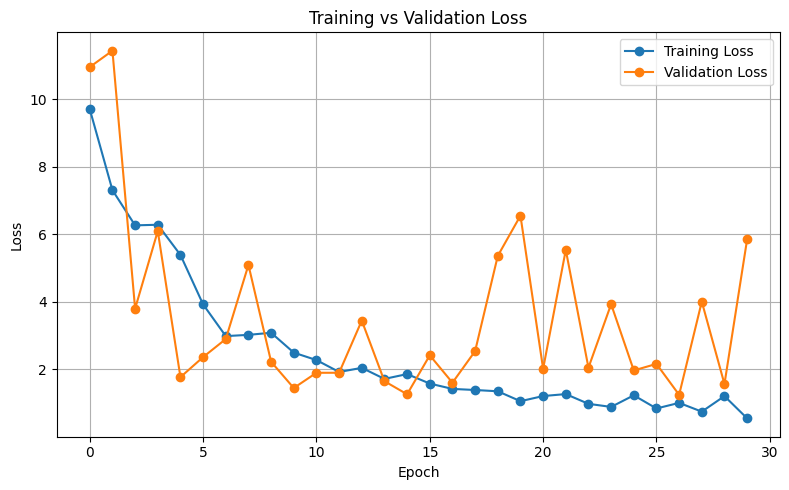

In [20]:

# Plot training and validation loss per epoch for a single run (e.g., history1) as an example
import matplotlib.pyplot as plt

epochs = list(range(len(history1['train_loss'])))
train_loss = history1['train_loss']
val_loss = history1['val_loss']

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', label='Training Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

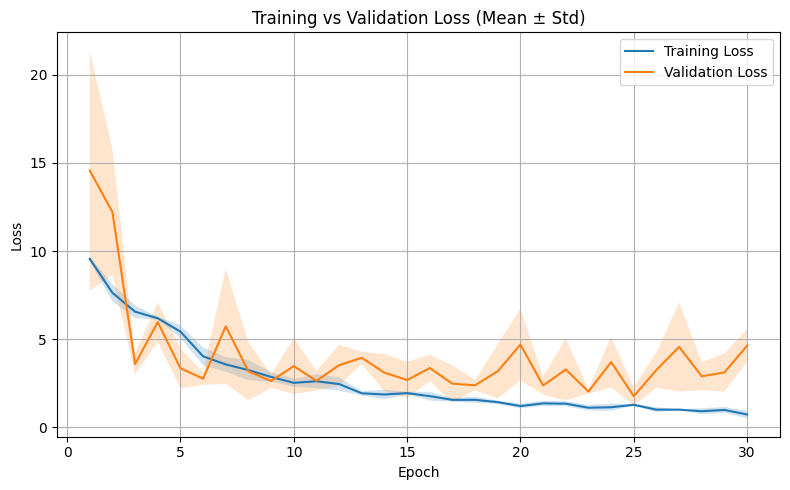

In [21]:
# Plot training and validation loss per epoch mean ± std across multiple runs (if available)
import numpy as np
import matplotlib.pyplot as plt

# Shape: (num_runs, num_epochs)
train_losses = np.array([
    history1['train_loss'],  # run 1
    history2['train_loss'],  # run 2
    history3['train_loss'],  # run 3
])

val_losses = np.array([
    history1['val_loss'],
    history2['val_loss'],
    history3['val_loss'],
])

epochs = np.arange(1, train_losses.shape[1] + 1)

train_mean = train_losses.mean(axis=0)
train_std = train_losses.std(axis=0)

val_mean = val_losses.mean(axis=0)
val_std = val_losses.std(axis=0)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_mean, label='Training Loss')
plt.fill_between(epochs,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.plot(epochs, val_mean, label='Validation Loss')
plt.fill_between(epochs,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Mean ± Std)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

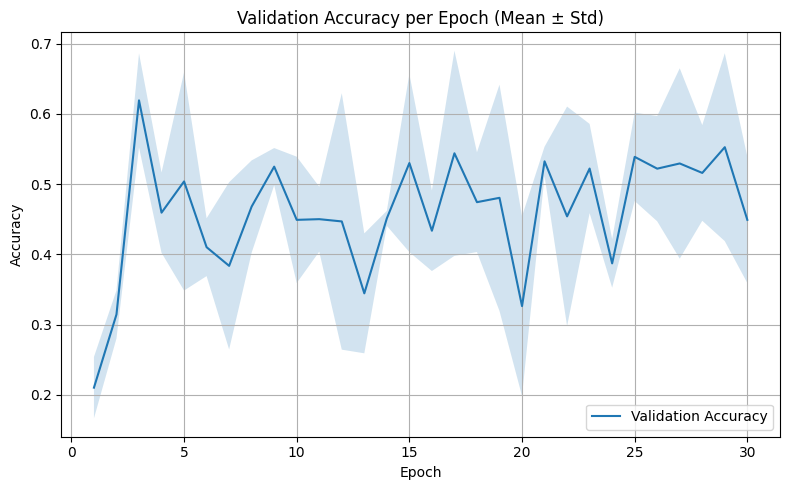

In [22]:
# Plot validation accuracy per epoch mean ± std across multiple runs
import numpy as np
import matplotlib.pyplot as plt

# Shape: (num_runs, num_epochs)
val_accuracies = np.array([
    history1['val_accuracy'],  # run 1
    history2['val_accuracy'],  # run 2
    history3['val_accuracy'],  # run 3
])

epochs = np.arange(1, val_accuracies.shape[1] + 1)

val_acc_mean = val_accuracies.mean(axis=0)
val_acc_std = val_accuracies.std(axis=0)

plt.figure(figsize=(8, 5))

plt.plot(epochs, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs,
                 val_acc_mean - val_acc_std,
                 val_acc_mean + val_acc_std,
                 alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy per Epoch (Mean ± Std)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()